In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
%matplotlib inline

In [2]:
df = pd.read_excel('../data/sample_-_superstore.xls')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [5]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter

df[['Order Date','Year','Month','Quarter']].head()

,Order Date,Year,Month,Quarter
0,2016-11-08,2016,November,4
1,2016-11-08,2016,November,4
2,2016-06-12,2016,June,2
3,2015-10-11,2015,October,4
4,2015-10-11,2015,October,4


In [9]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

In [10]:
print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value,2))
print("Profit Margin (%):", round(profit_margin,2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Average Order Value: 458.61
Profit Margin (%): 12.47


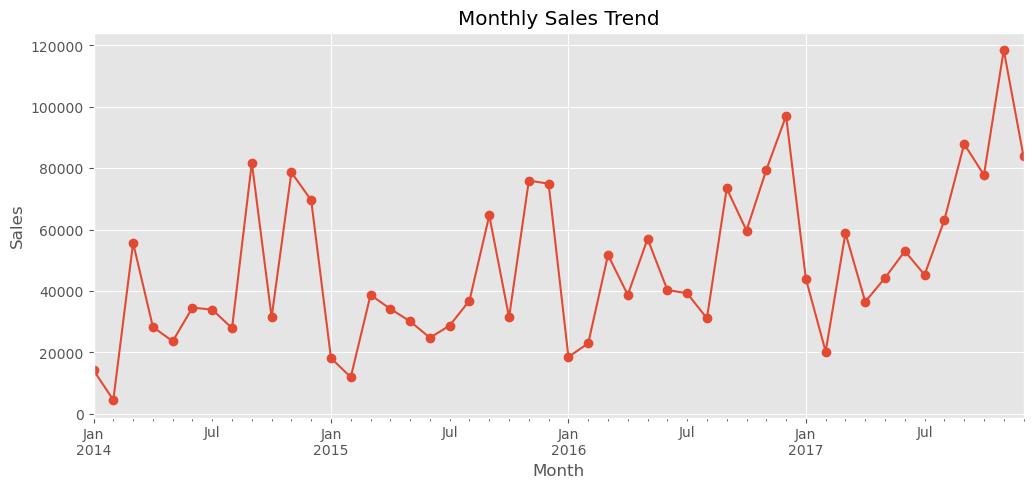

In [12]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.savefig('../output/charts/monthly_sales.png')

plt.show()

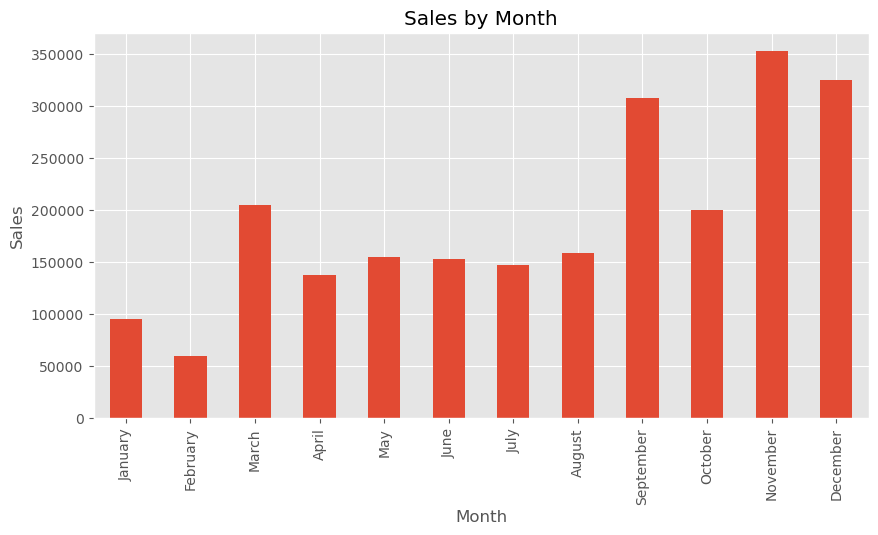

In [13]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

seasonality = df.groupby('Month')['Sales'].sum()
seasonality = seasonality.reindex(month_order)

plt.figure(figsize=(10,5))

seasonality.plot(kind='bar')

plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.savefig('../output/charts/seasonal_sales.png')

plt.show()

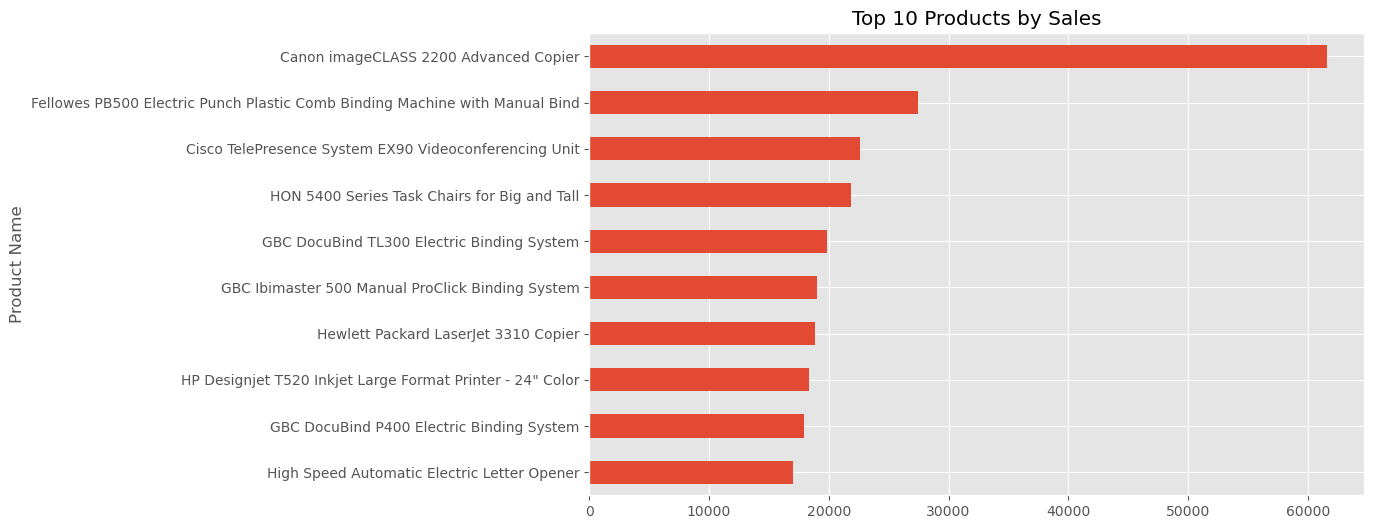

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [14]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')

plt.savefig('../output/charts/top_products.png')

plt.show()

print(top_products)

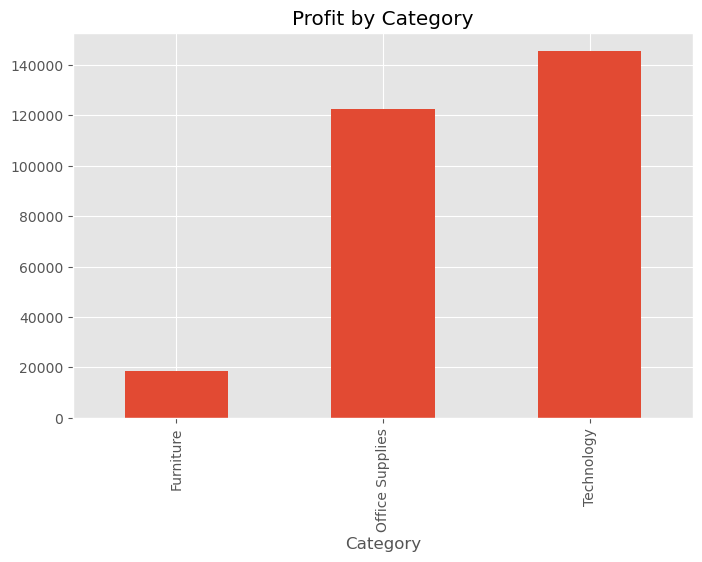

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [15]:
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title('Profit by Category')

plt.savefig('../output/charts/category_profit.png')

plt.show()

print(category_profit)

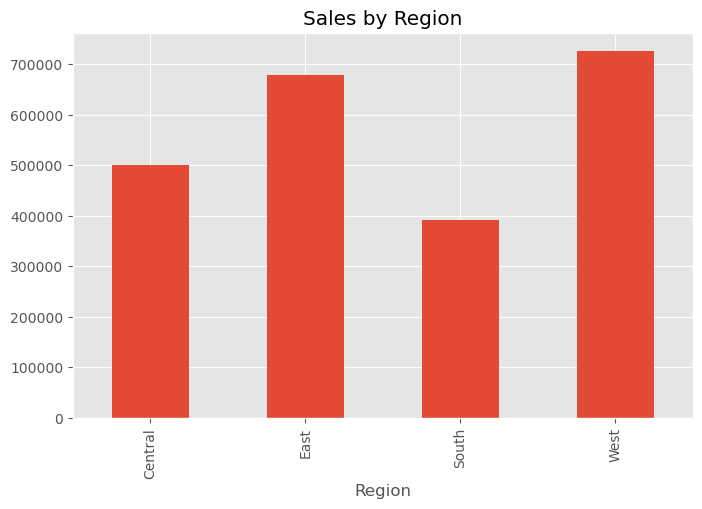

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [16]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')

plt.savefig('../output/charts/region_sales.png')

plt.show()

print(region_sales)

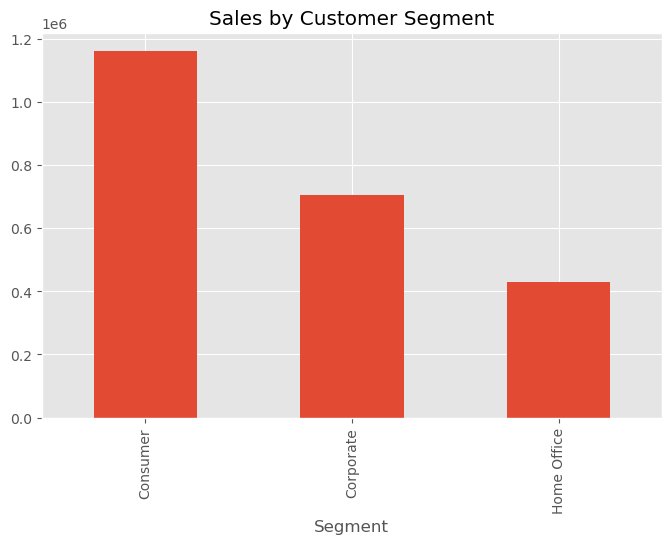

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


In [17]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar')

plt.title('Sales by Customer Segment')

plt.savefig('../output/charts/segment_sales.png')

plt.show()

print(segment_sales)

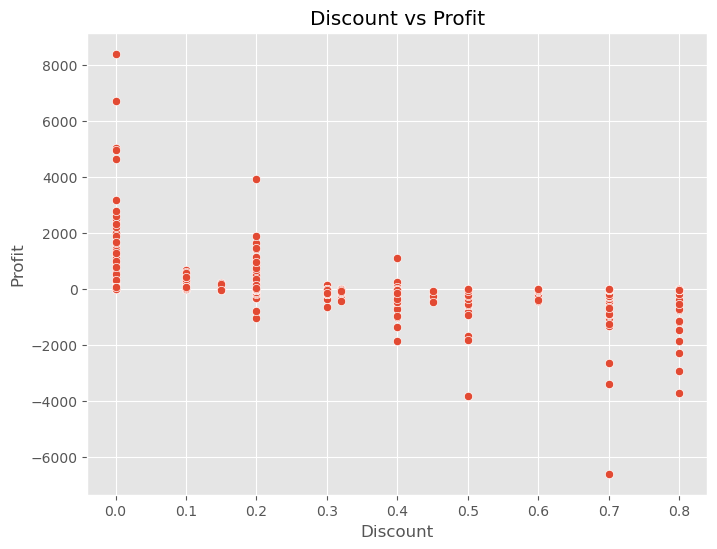

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title('Discount vs Profit')

plt.savefig('../output/charts/discount_profit.png')

plt.show()

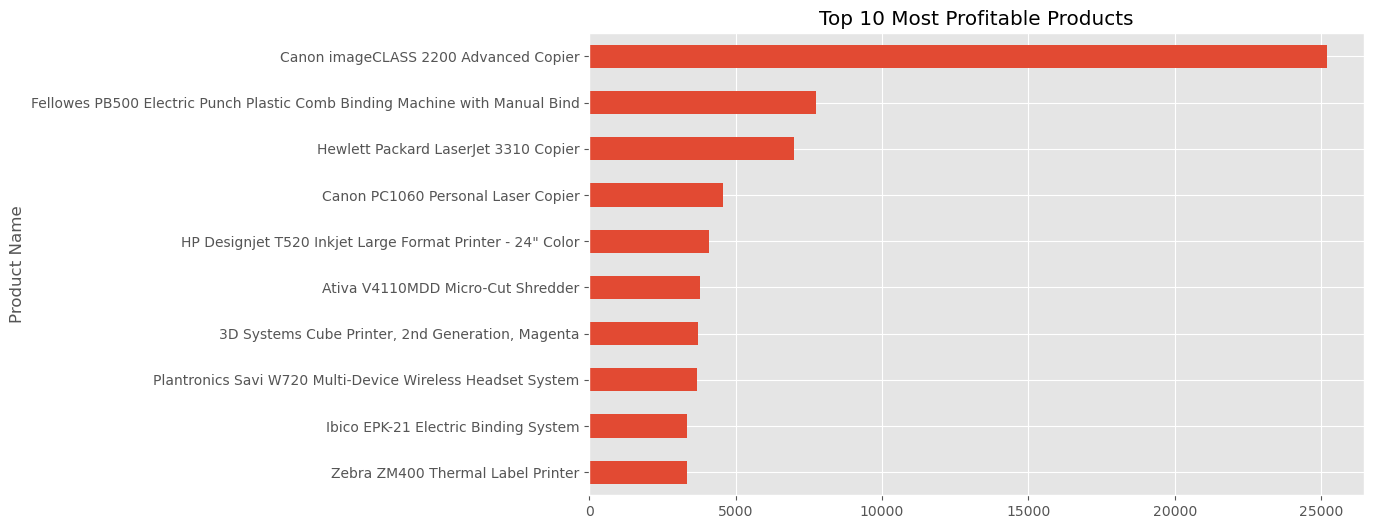

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [19]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_profit_products.sort_values().plot(kind='barh')

plt.title('Top 10 Most Profitable Products')

plt.savefig('../output/charts/top_profit_products.png')

plt.show()

print(top_profit_products)

In [20]:
loss_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


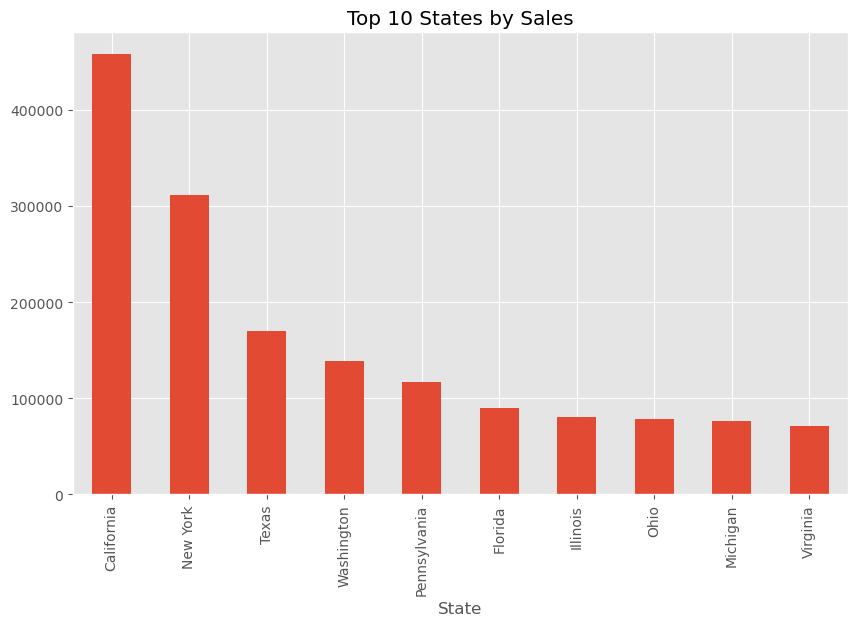

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


In [21]:
state_sales = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

state_sales.head(10).plot(kind='bar')

plt.title('Top 10 States by Sales')

plt.savefig('../output/charts/state_sales.png')

plt.show()

print(state_sales.head(10))

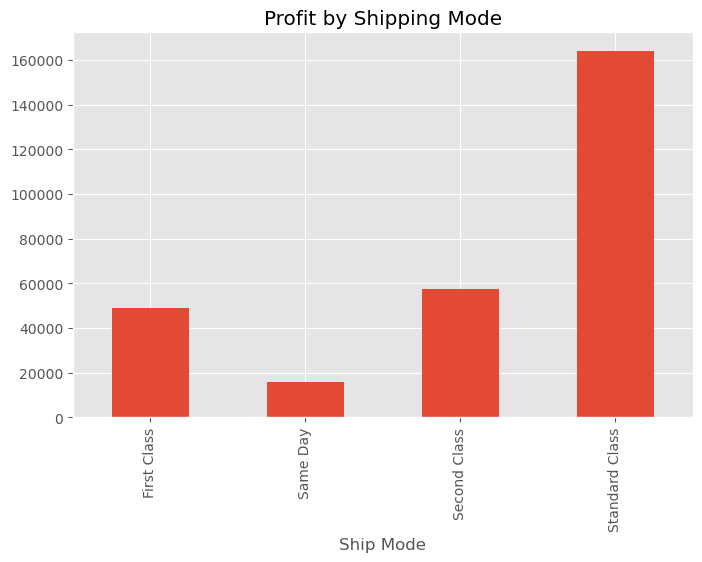

Ship Mode
First Class        48969.8399
Same Day           15891.7589
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64


In [22]:
ship_profit = df.groupby('Ship Mode')['Profit'].sum()

plt.figure(figsize=(8,5))

ship_profit.plot(kind='bar')

plt.title('Profit by Shipping Mode')

plt.savefig('../output/charts/shipping_profit.png')

plt.show()

print(ship_profit)

## Key Insights
##### November and December recorded peak sales.
##### Technology category generated the highest profits.
##### Consumer customers contributed the highest revenue.
##### Excessive discounting negatively impacted profitability.
##### Certain products consistently generated losses.
##### Some states significantly outperformed others.

## Recommendations
##### Increase inventory before Q4.
##### Optimize discount strategies.
##### Focus marketing budgets on high-profit products.
##### Review loss-making products.
##### Strengthen operations in underperforming regions.
##### Encourage the use of profitable shipping methods.